In [ ]:
!pip install tensorflow opencv-python imutils scikit-learn matplotlib

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving face-mask-dataset..zip to face-mask-dataset. (1).zip


In [ ]:
import zipfile

zip_path = "/content/face-mask-dataset. (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [ ]:
import os

print(os.listdir("/content/dataset"))

['data']


In [ ]:
print(os.listdir("/content/dataset/data"))

['without_mask', 'with_mask']


In [ ]:
dataset_path = "/content/dataset/data"

In [ ]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [ ]:
print(train_data.samples)
print(val_data.samples)
print(train_data.class_indices)

6043
1510
{'with_mask': 0, 'without_mask': 1}


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

baseModel = MobileNetV2(weights="imagenet", include_top=False,
                        input_shape=(224, 224, 3))

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(1, activation="sigmoid")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)

# Freeze base layers
for layer in baseModel.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
from tensorflow.keras.optimizers import Adam

INIT_LR = 1e-4
EPOCHS = 10

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=INIT_LR),
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // 32,
    validation_data=val_data,
    validation_steps=val_data.samples // 32,
    epochs=EPOCHS
)

Epoch 1/10
  8/188 ━━━━━━━━━━━━━━━━━━━━ 6:10 2s/step - accuracy: 0.5421 - loss: 0.8069

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


188/188 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.9216 - loss: 0.2013 - val_accuracy: 0.9834 - val_loss: 0.0644
Epoch 2/10
  1/188 ━━━━━━━━━━━━━━━━━━━━ 3:21 1s/step - accuracy: 0.9375 - loss: 0.1132

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


188/188 ━━━━━━━━━━━━━━━━━━━━ 59s 308ms/step - accuracy: 0.9375 - loss: 0.1132 - val_accuracy: 0.9827 - val_loss: 0.0645
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9814 - loss: 0.0613 - val_accuracy: 0.9867 - val_loss: 0.0402
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 80s 423ms/step - accuracy: 0.9688 - loss: 0.0437 - val_accuracy: 0.9867 - val_loss: 0.0406
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.9860 - loss: 0.0437 - val_accuracy: 0.9880 - val_loss: 0.0349
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 68s 358ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 0.9880 - val_loss: 0.0350
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9915 - loss: 0.0310 - val_accuracy: 0.9900 - val_loss: 0.0311
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 438ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.9894 - val_loss: 0.0309
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9923 - loss: 0.0257 - val_accurac

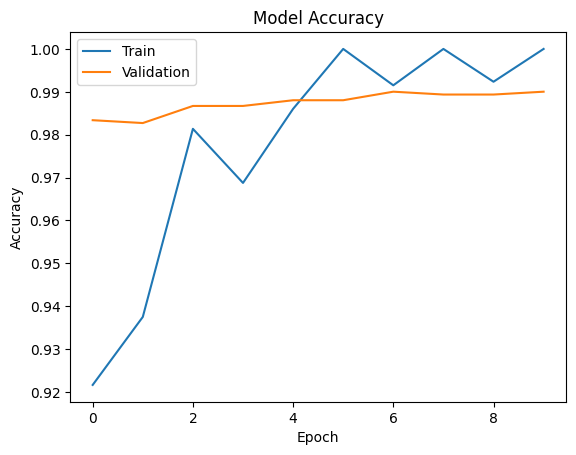

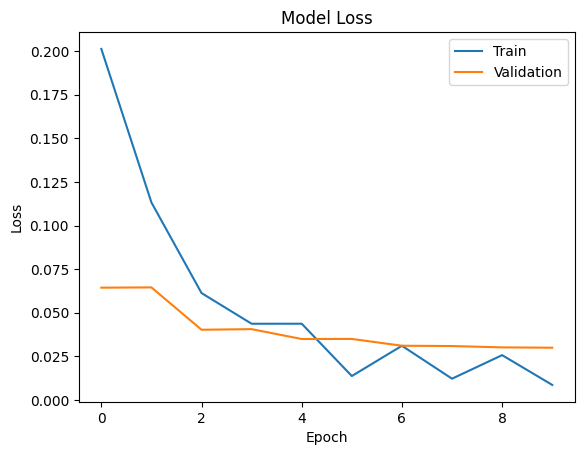

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
from sklearn.metrics import classification_report

preds = model.predict(val_data)
preds = (preds > 0.5).astype("int32")

print(classification_report(val_data.classes, preds))

48/48 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step
              precision    recall  f1-score   support

           0       0.50      0.50      0.50       745
           1       0.52      0.52      0.52       765

    accuracy                           0.51      1510
   macro avg       0.51      0.51      0.51      1510
weighted avg       0.51      0.51      0.51      1510



In [ ]:
model.save("face_mask_detector.h5")

In [ ]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml

--2026-04-17 10:02:03--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.02s   

2026-04-17 10:02:03 (41.8 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]



In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

def detect_mask(image_path):
    img = cv2.imread(image_path)
    orig = img.copy()
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = face_cascade.detectMultiScale(rgb, 1.1, 4)

    for (x, y, w, h) in faces:
        face = orig[y:y+h, x:x+w]
        face = cv2.resize(face, (224, 224))
        face = preprocess_input(face)
        face = np.expand_dims(face, axis=0)

        pred = model.predict(face)[0][0]

        label = "Mask" if pred < 0.5 else "No Mask"
        color = (0, 255, 0) if label == "Mask" else (0, 0, 255)

        cv2.putText(orig, label, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        cv2.rectangle(orig, (x, y), (x+w, y+h), color, 2)

    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.axis("off")

In [ ]:
from google.colab import files
files.upload()

Saving with_mask_993.jpg to with_mask_993.jpg


{'with_mask_993.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02\x01\x01\x01\x02\x02\x02\x02\x02\x04\x03\x02\x02\x02\x02\x05\x04\x04\x03\x04\x06\x05\x06\x06\x06\x05\x06\x06\x06\x07\t\x08\x06\x07\t\x07\x06\x06\x08\x0b\x08\t\n\n\n\n\n\x06\x08\x0b\x0c\x0b\n\x0c\t\n\n\n\xff\xdb\x00C\x01\x02\x02\x02\x02\x02\x02\x05\x03\x03\x05\n\x07\x06\x07\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\xff\xc0\x00\x11\x08\x00\xe4\x00\x9c\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x9

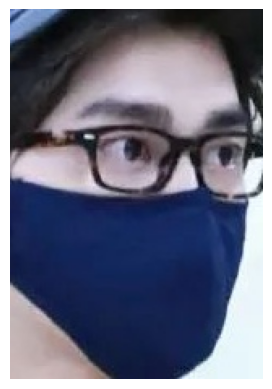

In [ ]:
detect_mask("with_mask_993.jpg")

In [ ]:
from google.colab import files
files.upload()

Saving without_mask_92.jpg to without_mask_92.jpg


{'without_mask_92.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02\x01\x01\x01\x02\x02\x02\x02\x02\x04\x03\x02\x02\x02\x02\x05\x04\x04\x03\x04\x06\x05\x06\x06\x06\x05\x06\x06\x06\x07\t\x08\x06\x07\t\x07\x06\x06\x08\x0b\x08\t\n\n\n\n\n\x06\x08\x0b\x0c\x0b\n\x0c\t\n\n\n\xff\xdb\x00C\x01\x02\x02\x02\x02\x02\x02\x05\x03\x03\x05\n\x07\x06\x07\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\xff\xc0\x00\x11\x08\x00\x8c\x00\x91\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


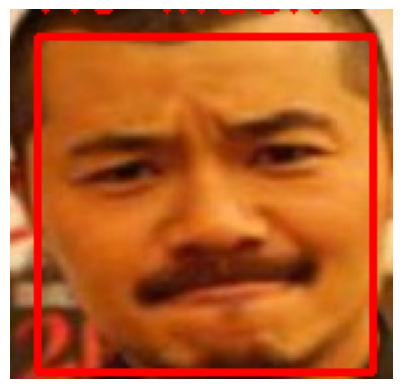

In [ ]:
detect_mask("without_mask_92.jpg")